<a href="https://colab.research.google.com/github/LIBY70/Deep_learning/blob/main/DL26_1_prac1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch [10/50], Train Loss: 49.5650, Val Loss: 34.5253
Epoch [20/50], Train Loss: 38.6900, Val Loss: 21.1681
Epoch [30/50], Train Loss: 29.8009, Val Loss: 18.4222
Epoch [40/50], Train Loss: 25.5897, Val Loss: 17.5066
Epoch [50/50], Train Loss: 28.5480, Val Loss: 15.8834


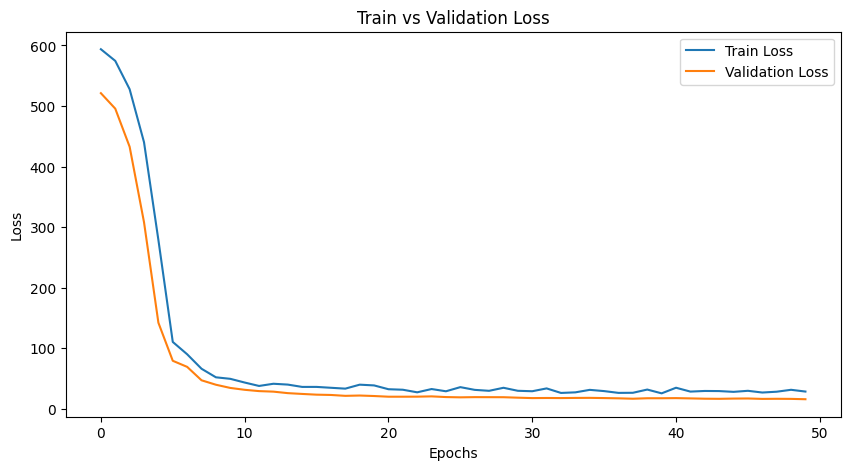

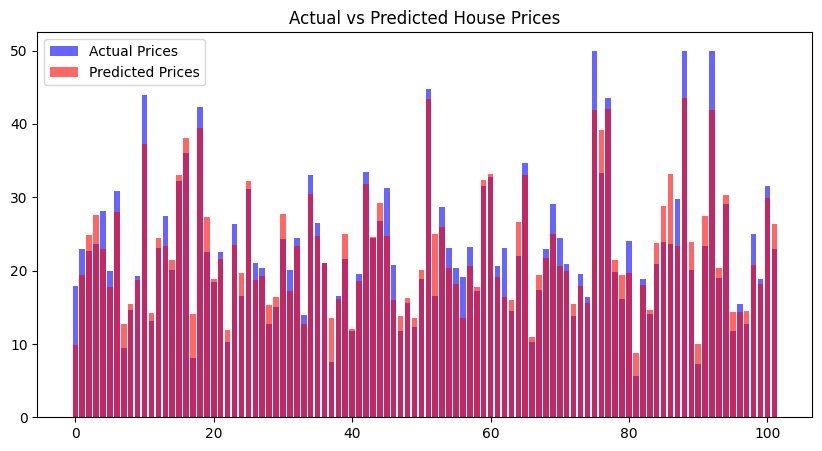

In [5]:
#### 예제1 - 수치 데이터 예측 ####

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. 데이터셋 로드
file_path = 'https://raw.githubusercontent.com/blackdew/tensorflow1/master/csv/boston.csv'
boston = pd.read_csv(file_path)

#X_data = boston[['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']].values  # 입력 데이터
X_data = boston.drop(['medv'], axis=1)  # 입력 데이터
y_data = boston[['medv']].values  # 목표 데이터 (집 가격)

# 4. 데이터 스케일링
scaler = StandardScaler()
X_data_scaled = scaler.fit_transform(X_data)

# 5. 데이터셋을 텐서로 변환
X = torch.tensor(X_data_scaled, dtype=torch.float32)
y = torch.tensor(y_data, dtype=torch.float32)

# 6. 데이터셋 나누기 (학습, 검증, 테스트)
dataset = TensorDataset(X, y)
train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=test_size, shuffle=False)

# 7. 신경망 모델 정의
class BostonModel(nn.Module):
    def __init__(self, input_size):
        super(BostonModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.fc4(x)
        return x

# 8. 모델 생성 및 초기화
input_size = 13
model = BostonModel(input_size=input_size)

# 9. 손실 함수 및 옵티마이저 정의
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# 10. 학습 및 검증 함수 정의
def train_and_validate(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=100):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # 검증 손실 계산
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        # 학습률 업데이트
        scheduler.step()

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    return train_losses, val_losses

# 11. 학습 및 검증 실행
epochs = 50
train_losses, val_losses = train_and_validate(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs)

# 12. 테스트 데이터 예측 및 시각화
model.eval()

with torch.no_grad():
    for inputs, targets in test_loader:
        predictions = model(inputs).squeeze()
        actual_prices = targets.squeeze()

# 13. 학습 및 검증 손실 시각화
plt.figure(figsize=(10, 5))
plt.plot(range(epochs), train_losses, label="Train Loss")
plt.plot(range(epochs), val_losses, label="Validation Loss")
plt.title("Train vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 14. 테스트 결과 시각화
plt.figure(figsize=(10, 5))
plt.bar(range(len(actual_prices)), actual_prices, color='b', alpha=0.6, label='Actual Prices')
plt.bar(range(len(predictions)), predictions, color='r', alpha=0.6, label='Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.show()


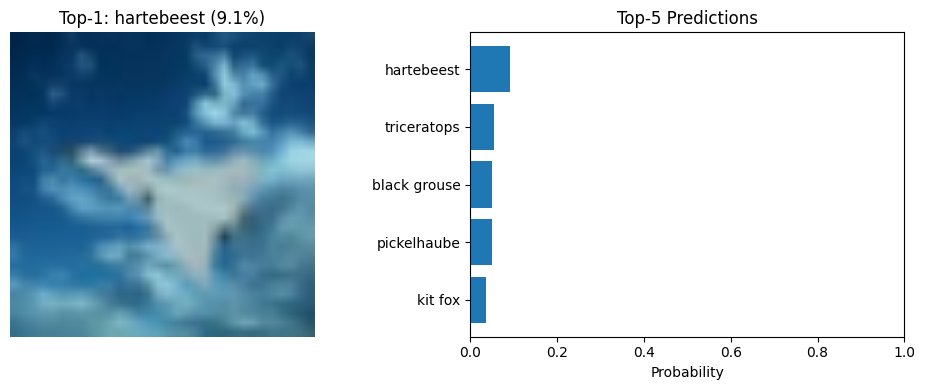

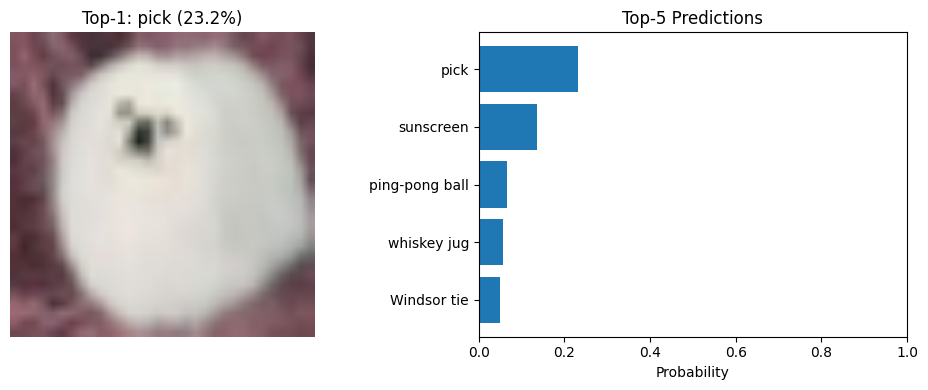

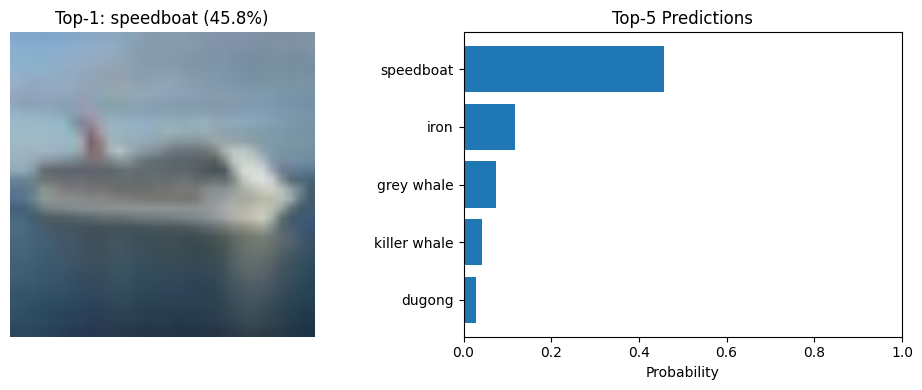

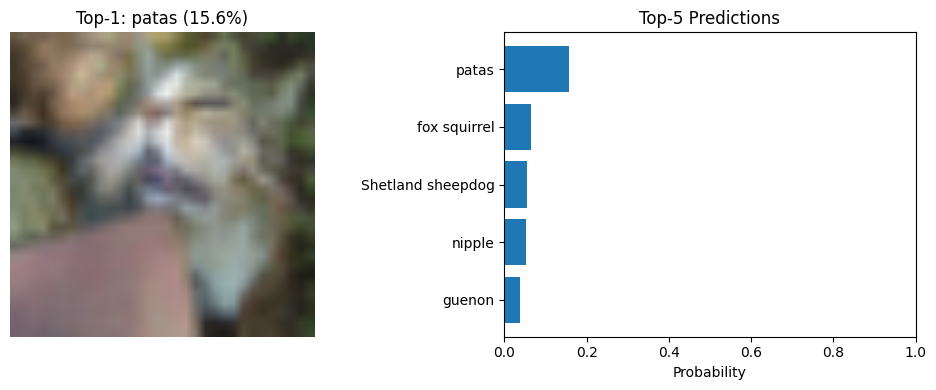

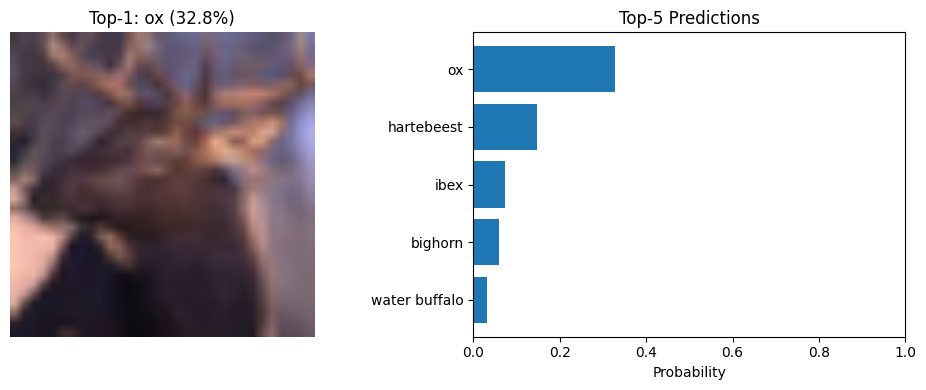

In [6]:
#### 예제2 - 이미지 분류 ####

import torch
import torch.nn.functional as F
from torchvision import models, datasets, transforms
from torchvision.models import MobileNet_V3_Small_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random

# ---- 1) 사전학습 모델 로드 ----
weights = MobileNet_V3_Small_Weights.DEFAULT
model = models.mobilenet_v3_small(weights=weights).eval()
preprocess = weights.transforms()
classes = weights.meta["categories"]

# ---- 2) CIFAR10 데이터셋(작고 빠름) ----
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ImageNet 크기로 리사이즈
    transforms.ToTensor(),
])
dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

# ---- 3) 랜덤 이미지 선택 ----
num_samples = 5  # 원하는 개수
indices = random.sample(range(len(dataset)), num_samples)

def topk_predictions(logits, k=5):
    probs = F.softmax(logits, dim=1)[0]
    topk_prob, topk_idx = torch.topk(probs, k)
    topk_prob = topk_prob.detach().cpu().numpy()
    topk_idx = topk_idx.detach().cpu().numpy()
    topk_lbl = [classes[i] for i in topk_idx]
    return topk_lbl, topk_prob

# ---- 4) 각 이미지 예측 및 시각화 ----
for idx in indices:
    img, _ = dataset[idx]
    pil_img = transforms.ToPILImage()(img)
    inp = preprocess(pil_img).unsqueeze(0)

    with torch.no_grad():
        logits = model(inp)

    labels, probs = topk_predictions(logits, k=5)
    top1 = f"{labels[0]} ({probs[0]*100:.1f}%)"

    fig = plt.figure(figsize=(10,4))
    ax1 = fig.add_subplot(1,2,1)
    ax1.imshow(pil_img)
    ax1.set_title(f"Top-1: {top1}")
    ax1.axis("off")

    ax2 = fig.add_subplot(1,2,2)
    y_pos = np.arange(len(labels))
    ax2.barh(y_pos, probs)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([l[:28] for l in labels])
    ax2.invert_yaxis()
    ax2.set_xlim(0, 1)
    ax2.set_xlabel("Probability")
    ax2.set_title("Top-5 Predictions")

    plt.tight_layout()
    plt.show()


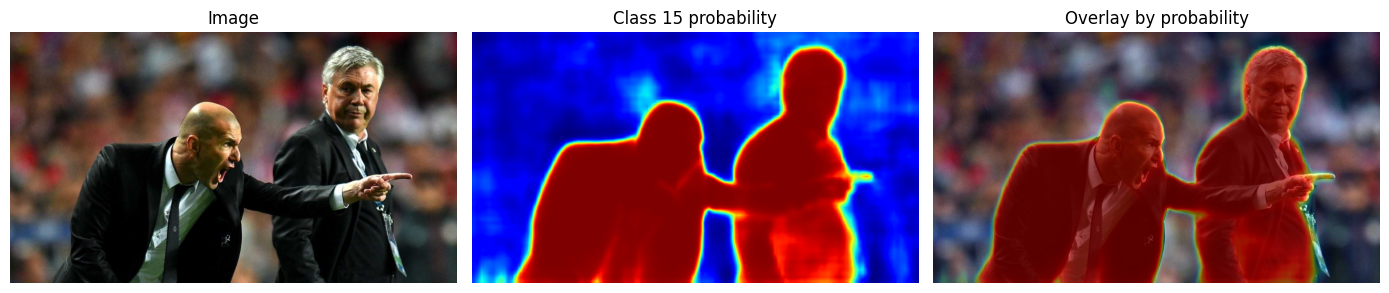

'\n0: background\n1: aeroplane   2: bicycle   3: bird      4: boat        5: bottle\n6: bus         7: car       8: cat       9: chair       10: cow\n11: diningtable 12: dog     13: horse    14: motorbike  15: person\n16: pottedplant 17: sheep   18: sofa     19: train      20: tv/monitor\n'

In [7]:
#### 예제3 - 이미지 분할 ####

# pip install torch torchvision pillow matplotlib requests
import torch
from torchvision import models
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO
import torch.nn.functional as F

# 1) 모델/가중치
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = models.segmentation.deeplabv3_resnet50(weights=weights).eval()
preprocess = weights.transforms()

# 2) 이미지
url = "https://ultralytics.com/images/zidane.jpg"
img = Image.open(BytesIO(requests.get(url, timeout=10).content)).convert("RGB")

# 3) 추론(softmax 확률 얻기)
inp = preprocess(img).unsqueeze(0)
w, h = img.size
with torch.no_grad():
    out = model(inp)["out"]                # [1, C, H', W']
    out_up = F.interpolate(out, size=(h, w), mode="bilinear", align_corners=False)
    prob = F.softmax(out_up, dim=1)[0].cpu().numpy()  # [C, H, W]

# 4) 가장 확률 높은 클래스(픽셀별 argmax)와 해당 확률 맵 시각화
pred_cls = prob.argmax(0)                  # [H, W]
pred_conf = prob.max(0)                    # (H, W) 각 픽셀의 top-class 확률

# 5) 특정 클래스(예: pred에서 가장 많이 나온 클래스)를 골라 그 확률 맵을 heatmap으로
#    (혹은 원하는 클래스 인덱스를 직접 지정 가능)
counts = np.bincount(pred_cls.flatten())
focus_cls = counts[1:].argmax()+1 if len(counts)>1 else 0   # 배경 제외 최빈 클래스 가정
focus_prob = prob[focus_cls]  # [H, W], 이 클래스의 픽셀별 확률

# 6) 확률 맵을 알파로 써서 오버레이
base = np.array(img).astype(np.float32)
heat = (plt.cm.jet(focus_prob)[:,:,:3]*255).astype(np.float32)  # colormap 적용 (0~1→0~255)
alpha = (focus_prob*0.7)[...,None]                              # 확률 기반 가변 알파
overlay = (alpha*heat + (1-alpha)*base).astype(np.uint8)

plt.figure(figsize=(14,5))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Image"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(focus_prob, cmap="jet"); plt.title(f"Class {focus_cls} probability"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(overlay); plt.title("Overlay by probability"); plt.axis("off")
plt.tight_layout(); plt.show()

'''
0: background
1: aeroplane   2: bicycle   3: bird      4: boat        5: bottle
6: bus         7: car       8: cat       9: chair       10: cow
11: diningtable 12: dog     13: horse    14: motorbike  15: person
16: pottedplant 17: sheep   18: sofa     19: train      20: tv/monitor
'''


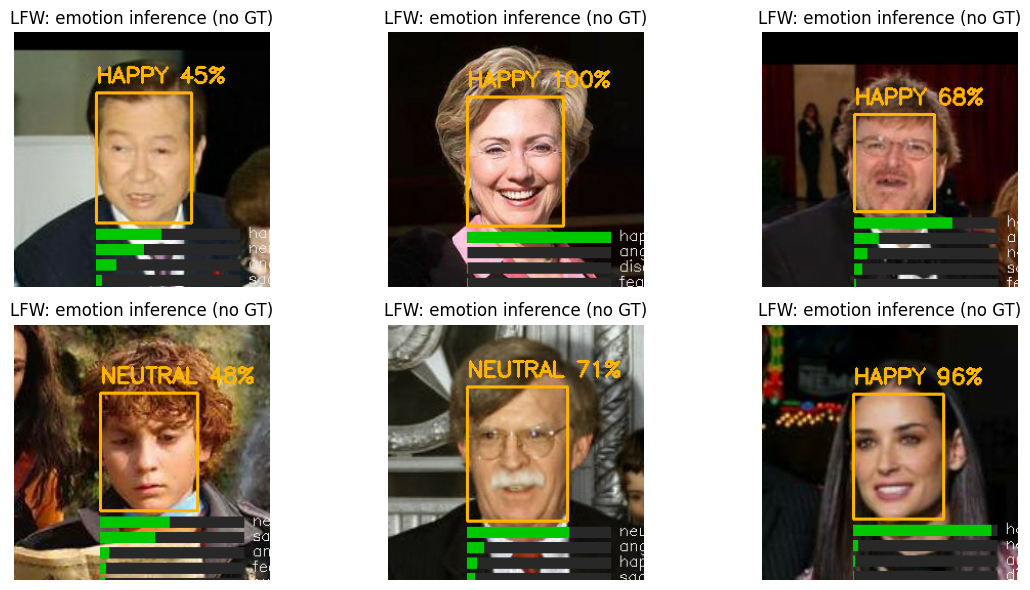

In [8]:
#### 예제4 - 객체 탐지 ####


# =========================================
#  LFW(TFDS) → 랜덤 얼굴 감정 분류 시각화
# =========================================

!pip -q install tensorflow-datasets fer==22.5.1 mtcnn opencv-python pillow matplotlib

import warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

from fer.fer import FER  # fer 최신 구조

# 1) 데이터셋 로드 (LFW는 얼굴 이미지로 구성 / 감정 GT 없음)
#    splits 예: 'train', 'test' (TFDS 내부 정의에 따라 다를 수 있음)
ds = tfds.load("lfw", split="train", as_supervised=False)
ds_np = list(tfds.as_numpy(ds))  # 각 원소: {'image': HxWx3, 'label': str 등 메타}

# 2) 감정 분류기(MTCNN 사용)
detector = FER(mtcnn=True)

FONT = cv2.FONT_HERSHEY_SIMPLEX
BAR_W, BAR_H, MARGIN = 140, 10, 6

def draw_emotions(frame, box, emotions):
    x, y, w, h = box
    x, y = max(0, x), max(0, y)
    w, h = max(0, w), max(0, h)
    # 얼굴 박스
    cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 180, 255), 2)
    # Top 감정
    items = sorted(emotions.items(), key=lambda kv: kv[1], reverse=True)
    top_label, top_prob = items[0]
    cv2.putText(frame, f"{top_label.upper()} {int(top_prob*100)}%",
                (x, max(20, y-10)), FONT, 0.7, (0, 180, 255), 2)
    # 확률 막대
    start_y = y + h + MARGIN
    for i, (label, prob) in enumerate(items):
        bar_x, bar_y = x, start_y + i*(BAR_H+5)
        cv2.rectangle(frame, (bar_x, bar_y), (bar_x+BAR_W, bar_y+BAR_H), (40, 40, 40), -1)
        cv2.rectangle(frame, (bar_x, bar_y), (bar_x+int(BAR_W*prob), bar_y+BAR_H), (0, 200, 0), -1)
        cv2.putText(frame, f"{label:<10} {int(prob*100):3d}%", (bar_x+BAR_W+8, bar_y+BAR_H-2),
                    FONT, 0.5, (230,230,230), 1)

def visualize_sample(example):
    """
    example: {'image': np.ndarray(H,W,3), ...}
    고해상도 컬러 → 필요 시 축소 → 얼굴 감정 추론 → 시각화 이미지 반환(RGB)
    """
    img = example["image"]  # RGB, uint8일 확률 높음
    if img.dtype != np.uint8:
        img = np.clip(img, 0, 255).astype(np.uint8)
    if img.ndim == 2:  # 혹시 흑백일 경우
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[-1] == 1:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    # 너무 크면 축소(속도/메모리)
    MAX_SIDE = 1280
    h, w = img.shape[:2]
    scale = min(1.0, MAX_SIDE / max(h, w))
    if scale < 1.0:
        img = cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)

    # 감정 분석 (FER은 RGB 입력)
    results = detector.detect_emotions(img)
    frame = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    if results:
        for r in results:
            draw_emotions(frame, r["box"], r["emotions"])
    else:
        cv2.putText(frame, "No face detected", (10,30), FONT, 0.8, (0,0,255), 2)

    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# 3) 랜덤 N개 시각화
num_samples = 6
idxs = random.sample(range(len(ds_np)), k=num_samples)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(idxs, 1):
    vis = visualize_sample(ds_np[idx])
    plt.subplot(2, 3, i)
    plt.imshow(vis)
    plt.title("LFW: emotion inference (no GT)")
    plt.axis("off")
plt.tight_layout()
plt.show()
